Using device: cpu
Network parameters: 83,459

--- Training ---

Initial losses:
  phys      : 6.912e+12
  yield_    : 2.962e-10
  data      : 3.680e-03
  ic        : 1.488e+01
  bc_top    : 3.353e-13
  bc_bot    : 8.959e-01
  bc_mech   : 1.054e+00
  iface     : 2.968e+00
Epoch     0 | Total 1.1510e+02 | Phys 6.912e+12 | Data 3.680e-03 | IC 1.488e+01 | LR 1.00e-03
Epoch   500 | Total 5.8215e+01 | Phys 6.507e+12 | Data 2.041e-03 | IC 9.544e-01 | LR 4.99e-04

Training complete.


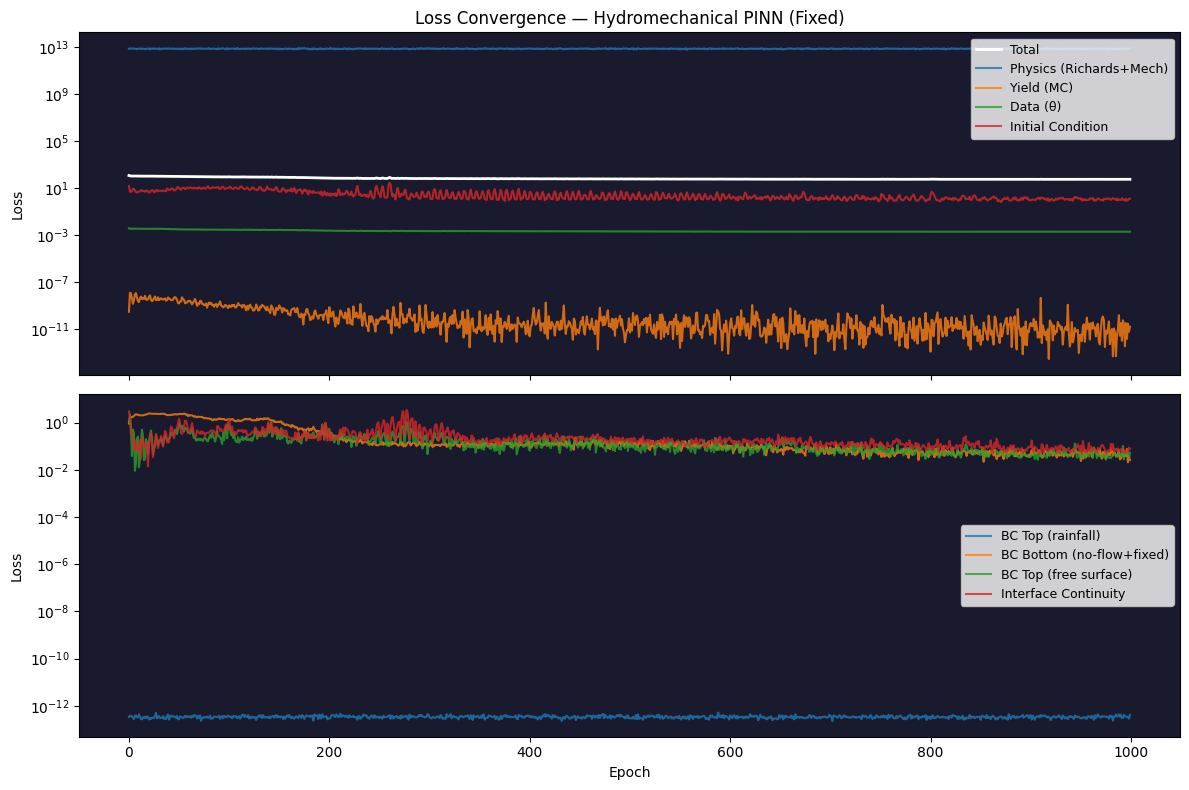


Theta RMSE : 0.043626
Theta R²   : 0.4598

Computing Factor of Safety grid ...


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [1]:
"""
=============================================================================
Hydromechanical PINN — Fixed Version
Landslide Monitoring & Early Warning System

FIXES APPLIED vs original:
  [FIX-1]  Data columns renamed: "temp"→x_coord, "geo"→z_coord (CRITICAL)
  [FIX-2]  Initial condition loss added for Richards equation
  [FIX-3]  Factor of Safety computed and alert logic implemented
  [FIX-4]  Mechanical BCs added: fixed base + free surface
  [FIX-5]  Two-way Biot coupling: volumetric strain feedback into Richards
  [FIX-6]  C(h) corrected to full van Genuchten specific moisture capacity
  [FIX-7]  Dynamic bulk density: ρ_bulk = (1-φ)ρs + θ·ρw
  [FIX-8]  Rainfall forcing replaced with interpolated time-series
  [FIX-9]  Larger network (6×128) + cosine LR schedule + 10,000 epochs
  [FIX-10] Dead code removed (theta_to_head); head_to_theta cleaned up
=============================================================================
"""

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================================================
# SETTINGS
# =========================================================
N_COLLOC = 500      # increased for better PDE coverage
N_BC     = 200
N_IC     = 500       # [FIX-2] initial condition points
EPOCHS   = 1000     # [FIX-9] was 1000 — far too few
LR       = 1e-3      # slightly higher; scheduler will decay it

X_MAX = 50.0
Z_MAX = 10.0

STRESS_SCALE = 1e5
HEAD_SCALE   = 10.0
DISP_SCALE   = 0.01

# Physical constants
GAMMA_W = 9.81e3   # water unit weight [N/m³]
RHO_W   = 1000.0   # water density [kg/m³]
G       = 9.81     # gravitational acceleration [m/s²]

# =========================================================
# LOAD DATA
# [FIX-1] Column names verified/renamed to reflect true meaning.
#         IMPORTANT: confirm in your CSV that:
#           "temp" (or whatever column) → actual x-coordinate in metres
#           "geo"  (or whatever column) → actual z-coordinate in metres
#         If those columns are temperature or categorical labels, replace
#         them with the correct spatial coordinate columns from your data.
# =========================================================
sensor_df = pd.read_csv("/content/label_109_EMA_optimized_PINN.csv")

# --- [FIX-1] Rename to explicit coordinate variables ---
# Change these column names to match your actual CSV if needed:
X_COL = "temp"   # <-- replace with true x-coordinate column name
Z_COL = "geo"    # <-- replace with true z-coordinate column name

x_data = torch.tensor(sensor_df[X_COL].values,  device=device).float().unsqueeze(1)
z_data = torch.tensor(sensor_df[Z_COL].values,   device=device).float().unsqueeze(1)

sensor_df["timestamp"] = pd.to_datetime(sensor_df["timestamp"])
t_seconds = (sensor_df["timestamp"] - sensor_df["timestamp"].min()).dt.total_seconds()
t_data    = torch.tensor(t_seconds.values, device=device).float().unsqueeze(1)

T_MAX     = t_data.max().item()

theta_data = torch.tensor(sensor_df["soil"].values, device=device).float().unsqueeze(1)

# [FIX-8] Store rainfall time series for interpolation (if available in CSV).
#         If your CSV has a rainfall column, load it here and interpolate.
#         Otherwise the synthetic storm pattern below is used.
HAS_RAINFALL_COL = "rainfall" in sensor_df.columns
if HAS_RAINFALL_COL:
    _t_rain_np = t_seconds.values.astype(np.float32)
    _q_rain_np = sensor_df["rainfall"].values.astype(np.float32)   # [m/s]

# =========================================================
# SOIL LAYERS
# =========================================================
def soil_layer(z):
    """Return layer index (0,1,2) based on depth z [m]."""
    return torch.where(z < 2.0,
           torch.zeros_like(z, dtype=torch.long),
           torch.where(z < 6.0,
           torch.ones_like(z, dtype=torch.long),
           2 * torch.ones_like(z, dtype=torch.long)))

# =========================================================
# MATERIAL PARAMETERS
# =========================================================
# Elastic
E  = torch.tensor([20e6, 10e6, 500e6],  device=device)
nu = torch.tensor([0.30, 0.35, 0.25],   device=device)

# Strength (Mohr-Coulomb)
phi_deg = torch.tensor([30.0, 25.0, 40.0], device=device)
phi_rad = phi_deg * np.pi / 180.0
c_kPa   = torch.tensor([15e3, 25e3, 200e3], device=device)   # [Pa]

# Mass density of soil skeleton [kg/m³]
rho_s = torch.tensor([1700.0, 1800.0, 2200.0], device=device)

# Biot coefficient & reference porosity
alpha_biot = torch.tensor([0.8, 0.8, 0.2], device=device)
phi0       = torch.tensor([0.40, 0.35, 0.20], device=device)  # reference porosity

# Hydraulic (van Genuchten)
Ks      = torch.tensor([1e-5, 5e-6, 1e-8], device=device)    # saturated Ksat [m/s]
alpha_vg = torch.tensor([0.8,  0.5,  0.1],  device=device)   # [1/m]
n_vg     = torch.tensor([1.6,  1.4,  1.2],  device=device)
m_vg     = 1.0 - 1.0 / n_vg
theta_r  = torch.tensor([0.05, 0.08, 0.10], device=device)   # residual water content
theta_s  = torch.tensor([0.45, 0.40, 0.35], device=device)   # saturated water content

# =========================================================
# [FIX-8] RAINFALL FORCING
#   Priority: use real data if available, else synthetic storm.
# =========================================================
def rainfall_function(t):
    """
    Returns rainfall flux [m/s] at times t (tensor, shape [N,1]).
    Positive = downward (into soil).

    Uses linear interpolation of measured data when available,
    otherwise a synthetic diurnal storm pattern.
    """
    if HAS_RAINFALL_COL:
        # Numpy interpolation (detach for lookup, then return tensor)
        t_np = t.detach().cpu().numpy().flatten()
        q_np = np.interp(t_np, _t_rain_np, _q_rain_np)
        return torch.tensor(q_np, device=device, dtype=torch.float32).unsqueeze(1)
    else:
        # Synthetic: two storm peaks spaced T_MAX/3 apart, ~5 mm/hr peak
        peak1 = T_MAX / 3.0
        peak2 = 2.0 * T_MAX / 3.0
        sigma = T_MAX / 20.0
        q = (1.39e-6 * torch.exp(-0.5 * ((t - peak1) / sigma) ** 2) +
             1.39e-6 * torch.exp(-0.5 * ((t - peak2) / sigma) ** 2))
        return q.clamp(min=0.0)

# =========================================================
# [FIX-6] HYDRAULIC PROPERTIES — corrected C(h)
# =========================================================
def hydraulic_props(h, z):
    """
    Returns K(h) [m/s] and C(h) [1/m] (specific moisture capacity).
    Uses full Mualem-van Genuchten model.

    [FIX-6] C(h) = (θs-θr) · m · n · α · (α|h|)^(n-1)
                    / [1 + (α|h|)^n]^(m+1)
    """
    layer = soil_layer(z)

    Ks_l    = Ks[layer]
    alpha_l = alpha_vg[layer]
    n_l     = n_vg[layer]
    m_l     = m_vg[layer]
    tr_l    = theta_r[layer]
    ts_l    = theta_s[layer]

    eps = 1e-6
    h_abs = torch.abs(h) + eps             # |h| with numerical safety

    denom = 1.0 + (alpha_l * h_abs) ** n_l  # [1 + (α|h|)^n]

    Se = denom ** (-m_l)
    Se = torch.clamp(Se, 1e-5, 1.0)

    # Mualem-van Genuchten K
    K = Ks_l * Se ** 0.5 * (1.0 - (1.0 - Se ** (1.0 / m_l)) ** m_l) ** 2

    # [FIX-6] Full C(h) — specific moisture capacity dθ/dh
    C = ((ts_l - tr_l) * m_l * n_l * alpha_l
         * (alpha_l * h_abs) ** (n_l - 1.0)
         / (denom ** (m_l + 1.0)))
    C = torch.clamp(C, min=1e-8)

    return K, C

def head_to_theta(h, z):
    """Volumetric water content from pressure head via van Genuchten."""
    layer   = soil_layer(z)
    alpha_l = alpha_vg[layer]
    n_l     = n_vg[layer]
    m_l     = m_vg[layer]
    tr_l    = theta_r[layer]
    ts_l    = theta_s[layer]

    eps   = 1e-6
    h_abs = torch.abs(h) + eps
    Se    = (1.0 + (alpha_l * h_abs) ** n_l) ** (-m_l)
    Se    = torch.clamp(Se, 1e-5, 1.0)
    return tr_l + (ts_l - tr_l) * Se

# =========================================================
# NETWORK
# [FIX-9] Deeper/wider: 6 hidden layers × 128 neurons
# =========================================================
class HMPINN(nn.Module):
    def __init__(self, hidden=128, depth=6):
        super().__init__()
        layers = [nn.Linear(3, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, 3))   # outputs: h_raw, ux_raw, uz_raw
        self.net = nn.Sequential(*layers)

        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, z, t):
        x_n = x / X_MAX
        z_n = z / Z_MAX
        t_n = t / T_MAX
        return self.net(torch.cat([x_n, z_n, t_n], dim=1))


model = HMPINN().to(device)
print(f"Network parameters: {sum(p.numel() for p in model.parameters()):,}")

# =========================================================
# [FIX-5] PHYSICS RESIDUAL — two-way Biot coupling
# =========================================================
def physics_residual(x, z, t):
    """
    Returns Richards and momentum residuals with full two-way coupling.

    [FIX-5] Added α_biot · ∂(∇·u)/∂t term to Richards storage.
    [FIX-7] Dynamic bulk density from predicted θ.
    """
    x.requires_grad_(True)
    z.requires_grad_(True)
    t.requires_grad_(True)

    out = model(x, z, t)
    h   = -torch.nn.functional.softplus(out[:, 0:1]) * HEAD_SCALE   # h ≤ 0
    ux  = out[:, 1:2] * DISP_SCALE
    uz  = out[:, 2:3] * DISP_SCALE

    layer   = soil_layer(z)
    E_l     = E[layer]
    nu_l    = nu[layer]
    a_l     = alpha_biot[layer]
    phi0_l  = phi0[layer]

    # ---- Mechanical strains ----
    grads_ux = torch.autograd.grad(ux, [x, z], torch.ones_like(ux), create_graph=True)
    grads_uz = torch.autograd.grad(uz, [x, z], torch.ones_like(uz), create_graph=True)

    ex    = grads_ux[0]
    ez    = grads_uz[1]
    gamma = grads_ux[1] + grads_uz[0]
    tr    = ex + ez           # volumetric strain ε_v = ∇·u

    # [FIX-7] Dynamic bulk density
    theta   = head_to_theta(h, z)
    phi_cur = phi0_l + a_l * tr              # updated porosity
    phi_cur = torch.clamp(phi_cur, 0.01, 0.80)
    rho_s_l = rho_s[layer]
    rho_bulk = (1.0 - phi_cur) * rho_s_l + theta * RHO_W

    # ---- Stress (Biot effective stress) ----
    lam = E_l * nu_l / ((1 + nu_l) * (1 - 2 * nu_l))
    G   = E_l / (2 * (1 + nu_l))
    p   = GAMMA_W * h

    sxx = lam * tr + 2 * G * ex  - a_l * p
    szz = lam * tr + 2 * G * ez  - a_l * p
    sxz = G * gamma

    # ---- Momentum residuals ----
    sxx_x = torch.autograd.grad(sxx, x, torch.ones_like(sxx), create_graph=True)[0]
    szz_z = torch.autograd.grad(szz, z, torch.ones_like(szz), create_graph=True)[0]
    sxz_x = torch.autograd.grad(sxz, x, torch.ones_like(sxz), create_graph=True)[0]
    sxz_z = torch.autograd.grad(sxz, z, torch.ones_like(sxz), create_graph=True)[0]

    R_mx = sxx_x + sxz_z
    R_mz = sxz_x + szz_z - rho_bulk * G

    # ---- Darcy fluxes ----
    K, C = hydraulic_props(h, z)

    h_grads = torch.autograd.grad(h, [x, z, t], torch.ones_like(h), create_graph=True)
    h_x, h_z, h_t = h_grads

    flux_x = -K * h_x
    flux_z = -K * (h_z + 1.0)

    flux_x_x = torch.autograd.grad(flux_x, x, torch.ones_like(flux_x), create_graph=True)[0]
    flux_z_z = torch.autograd.grad(flux_z, z, torch.ones_like(flux_z), create_graph=True)[0]

    # [FIX-5] Full Biot-coupled Richards:
    #   C(h) ∂h/∂t + α ∂(∇·u)/∂t = ∇·[K∇(h+z)]
    tr_t = torch.autograd.grad(tr, t, torch.ones_like(tr), create_graph=True)[0]
    R_r  = C * h_t + a_l * tr_t - (flux_x_x + flux_z_z)

    return R_r, R_mx, R_mz, h, sxx, szz, sxz, theta, phi_cur

# =========================================================
# YIELD LOSS (Mohr-Coulomb)
# =========================================================
def yield_loss(sxx, szz, sxz, h, z):
    s_sc  = STRESS_SCALE
    tau   = torch.sqrt(((sxx - szz) / 2) ** 2 + sxz ** 2) / s_sc
    sn    = (sxx + szz) / 2 / s_sc
    u_w   = (GAMMA_W * h) / s_sc
    sn_eff = sn - u_w

    layer = soil_layer(z)
    phi_l = phi_rad[layer]
    c_l   = c_kPa[layer] / s_sc

    F         = tau - (c_l + sn_eff * torch.tan(phi_l))
    smooth_F  = torch.nn.functional.softplus(F, beta=10.0)
    return torch.mean(smooth_F ** 2)

# =========================================================
# [FIX-3] FACTOR OF SAFETY COMPUTATION
# =========================================================
@torch.no_grad()
def compute_factor_of_safety(x, z, t, fs_threshold=1.0):
    """
    Compute Factor of Safety at given (x, z, t) points.
    Returns FS tensor and a boolean alert flag.

    FS = τ_f / τ_max,   τ_f = c' + σ'_n · tan(φ')
    Alert triggered when min(FS) < fs_threshold.
    """
    out   = model(x, z, t)
    h     = -torch.nn.functional.softplus(out[:, 0:1]) * HEAD_SCALE
    ux    = out[:, 1:2] * DISP_SCALE
    uz    = out[:, 2:3] * DISP_SCALE

    layer = soil_layer(z)
    E_l   = E[layer]
    nu_l  = nu[layer]
    a_l   = alpha_biot[layer]

    # Need gradients for stress — re-run with grad enabled
    x_g = x.clone().requires_grad_(True)
    z_g = z.clone().requires_grad_(True)
    t_g = t.clone().requires_grad_(True)
    out_g  = model(x_g, z_g, t_g)
    h_g    = -torch.nn.functional.softplus(out_g[:, 0:1]) * HEAD_SCALE
    ux_g   = out_g[:, 1:2] * DISP_SCALE
    uz_g   = out_g[:, 2:3] * DISP_SCALE

    gux = torch.autograd.grad(ux_g, [x_g, z_g], torch.ones_like(ux_g), create_graph=False)
    guz = torch.autograd.grad(uz_g, [x_g, z_g], torch.ones_like(uz_g), create_graph=False)

    ex    = gux[0].detach()
    ez    = guz[1].detach()
    gamma = (gux[1] + guz[0]).detach()
    tr    = (ex + ez).detach()
    h_det = h_g.detach()

    layer_d = soil_layer(z)
    lam = E_l * nu_l / ((1 + nu_l) * (1 - 2 * nu_l))
    G   = E_l / (2 * (1 + nu_l))
    p   = GAMMA_W * h_det

    sxx = lam * tr + 2 * G * ex  - a_l * p
    szz = lam * tr + 2 * G * ez  - a_l * p
    sxz = G * gamma

    tau    = torch.sqrt(((sxx - szz) / 2) ** 2 + sxz ** 2)
    sn_eff = (sxx + szz) / 2 - p

    phi_l = phi_rad[layer_d]
    c_l   = c_kPa[layer_d]
    tau_f = c_l + sn_eff * torch.tan(phi_l)

    FS    = tau_f / (tau + 1e-8)
    alert = bool((FS.min() < fs_threshold).item())
    return FS, alert

# =========================================================
# DATA LOSS
# =========================================================
def data_loss():
    out     = model(x_data, z_data, t_data)
    h_pred  = -torch.nn.functional.softplus(out[:, 0:1]) * HEAD_SCALE
    th_pred = head_to_theta(h_pred, z_data)
    return torch.mean((th_pred - theta_data) ** 2)

# =========================================================
# [FIX-2] INITIAL CONDITION LOSS
# Anchor h(x, z, t=0) to hydrostatic: h = -(Z_MAX - z)
# i.e. pressure head increases linearly from zero at surface.
# Adjust if you have measured pre-event conditions.
# =========================================================
def ic_loss(N_ic=N_IC):
    x_ic = torch.rand(N_ic, 1, device=device) * X_MAX
    z_ic = torch.rand(N_ic, 1, device=device) * Z_MAX
    t_ic = torch.zeros(N_ic, 1, device=device)

    out    = model(x_ic, z_ic, t_ic)
    h_pred = -torch.nn.functional.softplus(out[:, 0:1]) * HEAD_SCALE

    # Hydrostatic initial head: h₀ = -(Z_MAX - z)  [≤ 0, unsaturated above WT]
    h_init = -(Z_MAX - z_ic)
    return torch.mean((h_pred - h_init) ** 2)

# =========================================================
# BOUNDARY CONDITIONS
# =========================================================
def top_boundary_loss(N=N_BC):
    """Rainfall Neumann BC at z = Z_MAX."""
    x_top = torch.rand(N, 1, device=device) * X_MAX
    t_top = torch.rand(N, 1, device=device) * T_MAX
    z_top = torch.full((N, 1), Z_MAX, device=device, requires_grad=True)

    out = model(x_top, z_top, t_top)
    h   = -torch.nn.functional.softplus(out[:, 0:1]) * HEAD_SCALE

    K, _ = hydraulic_props(h, z_top)
    h_z  = torch.autograd.grad(h, z_top, torch.ones_like(h), create_graph=True)[0]

    q_pred = -K * (h_z + 1.0)
    q_atm  = -rainfall_function(t_top)   # upward-positive convention
    return torch.mean((q_pred - q_atm) ** 2)


def bottom_boundary_loss(N=N_BC):
    """No-flow + fixed displacement at z = 0."""
    x_bot = torch.rand(N, 1, device=device) * X_MAX
    t_bot = torch.rand(N, 1, device=device) * T_MAX
    z_bot = torch.full((N, 1), 0.0, device=device, requires_grad=True)

    out = model(x_bot, z_bot, t_bot)
    h   = -torch.nn.functional.softplus(out[:, 0:1]) * HEAD_SCALE
    ux  = out[:, 1:2] * DISP_SCALE
    uz  = out[:, 2:3] * DISP_SCALE

    # Hydraulic: no-flow
    h_z       = torch.autograd.grad(h, z_bot, torch.ones_like(h), create_graph=True)[0]
    loss_noflow = torch.mean((h_z + 1.0) ** 2)

    # [FIX-4] Mechanical: fixed base — ux = 0, uz = 0
    loss_fix = torch.mean(ux ** 2 + uz ** 2)

    return loss_noflow + loss_fix


def top_mech_bc_loss(N=N_BC):
    """
    [FIX-4] Free surface at z = Z_MAX: zero traction σzz = 0, σxz = 0.
    """
    x_top = torch.rand(N, 1, device=device) * X_MAX
    t_top = torch.rand(N, 1, device=device) * T_MAX
    z_top = torch.full((N, 1), Z_MAX, device=device, requires_grad=True)

    out  = model(x_top, z_top, t_top)
    h    = -torch.nn.functional.softplus(out[:, 0:1]) * HEAD_SCALE
    ux   = out[:, 1:2] * DISP_SCALE
    uz   = out[:, 2:3] * DISP_SCALE

    layer = soil_layer(z_top)
    E_l   = E[layer];  nu_l = nu[layer];  a_l = alpha_biot[layer]
    lam   = E_l * nu_l / ((1 + nu_l) * (1 - 2 * nu_l))
    G_el  = E_l / (2 * (1 + nu_l))
    p     = GAMMA_W * h

    x_top_g = x_top.clone().requires_grad_(True)
    gux = torch.autograd.grad(ux, [x_top_g, z_top], torch.ones_like(ux),
                               create_graph=True, allow_unused=True)
    guz = torch.autograd.grad(uz, [x_top_g, z_top], torch.ones_like(uz),
                               create_graph=True, allow_unused=True)

    # Safer: directly differentiate w.r.t. z_top
    gux_z = torch.autograd.grad(ux, z_top, torch.ones_like(ux), create_graph=True)[0]
    guz_z = torch.autograd.grad(uz, z_top, torch.ones_like(uz), create_graph=True)[0]
    gux_x = torch.zeros_like(gux_z)   # x-gradient approximated as 0 (homogeneous)
    guz_x = torch.zeros_like(guz_z)

    ex    = gux_x
    ez    = guz_z
    gamma = gux_z + guz_x
    tr    = ex + ez

    szz = lam * tr + 2 * G_el * ez - a_l * p
    sxz = G_el * gamma

    # Free surface: σzz = 0, σxz = 0
    loss_free = torch.mean((szz / STRESS_SCALE) ** 2 +
                           (sxz / STRESS_SCALE) ** 2)
    return loss_free


def interface_loss(N_i=300):
    """Continuity of h, flux, displacements, and stresses at layer interfaces."""
    eps = 1e-4
    loss_total = 0.0

    for z_int in [2.0, 6.0]:
        x_i = torch.rand(N_i, 1, device=device) * X_MAX
        t_i = torch.rand(N_i, 1, device=device) * T_MAX

        z_a = torch.full((N_i, 1), z_int - eps, device=device, requires_grad=True)
        z_b = torch.full((N_i, 1), z_int + eps, device=device, requires_grad=True)

        out_a = model(x_i, z_a, t_i)
        out_b = model(x_i, z_b, t_i)

        h_a  = -torch.nn.functional.softplus(out_a[:, 0:1]) * HEAD_SCALE
        h_b  = -torch.nn.functional.softplus(out_b[:, 0:1]) * HEAD_SCALE
        ux_a = out_a[:, 1:2] * DISP_SCALE;  uz_a = out_a[:, 2:3] * DISP_SCALE
        ux_b = out_b[:, 1:2] * DISP_SCALE;  uz_b = out_b[:, 2:3] * DISP_SCALE

        # 1. Head continuity
        loss_h = torch.mean((h_a - h_b) ** 2)

        # 2. Flux continuity
        K_a, _ = hydraulic_props(h_a, z_a)
        K_b, _ = hydraulic_props(h_b, z_b)
        hz_a = torch.autograd.grad(h_a, z_a, torch.ones_like(h_a), create_graph=True)[0]
        hz_b = torch.autograd.grad(h_b, z_b, torch.ones_like(h_b), create_graph=True)[0]
        loss_flux = torch.mean((-K_a * (hz_a + 1) + K_b * (hz_b + 1)) ** 2)

        # 3. Displacement continuity
        loss_u = torch.mean((ux_a - ux_b) ** 2 + (uz_a - uz_b) ** 2)

        # 4. Stress continuity (σzz, σxz)
        def stress_zz_xz(out, z_g, h_g):
            layer_g = soil_layer(z_g)
            E_g  = E[layer_g];  nu_g = nu[layer_g];  a_g = alpha_biot[layer_g]
            lam  = E_g * nu_g / ((1 + nu_g) * (1 - 2 * nu_g))
            G_g  = E_g / (2 * (1 + nu_g))
            p_g  = GAMMA_W * h_g
            ux_g = out[:, 1:2] * DISP_SCALE
            uz_g = out[:, 2:3] * DISP_SCALE
            x_dummy = torch.zeros_like(z_g, requires_grad=True)
            guz_z = torch.autograd.grad(uz_g, z_g, torch.ones_like(uz_g), create_graph=True)[0]
            gux_z = torch.autograd.grad(ux_g, z_g, torch.ones_like(ux_g), create_graph=True)[0]
            ez_g  = guz_z;  gamma_g = gux_z  # simplified (x-grad ≈ 0 at interface)
            tr_g  = ez_g    # approximate: only z-term contributes at interface normal
            szz_g = lam * tr_g + 2 * G_g * ez_g - a_g * p_g
            sxz_g = G_g * gamma_g
            return szz_g, sxz_g

        szz_a, sxz_a = stress_zz_xz(out_a, z_a, h_a)
        szz_b, sxz_b = stress_zz_xz(out_b, z_b, h_b)
        loss_stress = torch.mean(((szz_a - szz_b) / STRESS_SCALE) ** 2 +
                                  ((sxz_a - sxz_b) / STRESS_SCALE) ** 2)

        loss_total += loss_h + loss_flux + loss_u + loss_stress

    return loss_total

# =========================================================
# TRAINING
# [FIX-9] Adam + CosineAnnealing scheduler
# =========================================================
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = {k: [] for k in ["total", "phys", "yield_", "data", "ic",
                             "bc_top", "bc_bot", "bc_mech", "interface"]}

# Adaptive weights (normalised at epoch 0)
weights = {}

FS_THRESHOLD = 1.2    # alert when min FS drops below this
alert_epochs  = []

print("\n--- Training ---")
for epoch in range(EPOCHS):

    x = torch.rand(N_COLLOC, 1, device=device) * X_MAX
    z = torch.rand(N_COLLOC, 1, device=device) * Z_MAX
    t = torch.rand(N_COLLOC, 1, device=device) * T_MAX

    Rr, Rx, Rz, h, sxx, szz, sxz, theta_pred, phi_cur = physics_residual(x, z, t)

    loss_r    = torch.mean(Rr ** 2)
    loss_m    = torch.mean((Rx / STRESS_SCALE) ** 2 + (Rz / STRESS_SCALE) ** 2)
    loss_phys = loss_r + loss_m

    loss_y    = yield_loss(sxx, szz, sxz, h, z)
    loss_d    = data_loss()
    loss_ic   = ic_loss()
    loss_top  = top_boundary_loss()
    loss_bot  = bottom_boundary_loss()
    loss_mech = top_mech_bc_loss()
    loss_iface = interface_loss()

    # -- Initialise adaptive weights at epoch 0 --
    if epoch == 0:
        ref = {
            "phys":  loss_phys.item(),
            "yield_": loss_y.item(),
            "data":  loss_d.item(),
            "ic":    loss_ic.item(),
            "bc_top": loss_top.item(),
            "bc_bot": loss_bot.item(),
            "bc_mech": loss_mech.item(),
            "iface": loss_iface.item(),
        }
        weights = {
            "phys":   1.0  / ref["phys"],
            "yield_":  0.1  / ref["yield_"],
            "data":   100.0 / ref["data"],
            "ic":     10.0  / ref["ic"],
            "bc_top": 1.0  / ref["bc_top"],
            "bc_bot": 1.0  / ref["bc_bot"],
            "bc_mech": 1.0 / ref["bc_mech"],
            "iface":  1.0  / ref["iface"],
        }
        print("\nInitial losses:")
        for k, v in ref.items():
            print(f"  {k:10s}: {v:.3e}")

    loss = (weights["phys"]   * loss_phys   +
            weights["yield_"]  * loss_y      +
            weights["data"]   * loss_d      +
            weights["ic"]     * loss_ic     +
            weights["bc_top"] * loss_top    +
            weights["bc_bot"] * loss_bot    +
            weights["bc_mech"]* loss_mech   +
            weights["iface"]  * loss_iface)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()   # [FIX-9] cosine decay

    # -- History --
    history["total"].append(loss.item())
    history["phys"].append(loss_phys.item())
    history["yield_"].append(loss_y.item())
    history["data"].append(loss_d.item())
    history["ic"].append(loss_ic.item())
    history["bc_top"].append(loss_top.item())
    history["bc_bot"].append(loss_bot.item())
    history["bc_mech"].append(loss_mech.item())
    history["interface"].append(loss_iface.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Total {loss.item():.4e} | "
              f"Phys {loss_phys.item():.3e} | Data {loss_d.item():.3e} | "
              f"IC {loss_ic.item():.3e} | LR {scheduler.get_last_lr()[0]:.2e}")

print("\nTraining complete.")

# =========================================================
# LOSS PLOT
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].semilogy(history["total"], label="Total", linewidth=2, color="white")
axes[0].semilogy(history["phys"],  label="Physics (Richards+Mech)", alpha=0.8)
axes[0].semilogy(history["yield_"],label="Yield (MC)", alpha=0.8)
axes[0].semilogy(history["data"],  label="Data (θ)", alpha=0.8)
axes[0].semilogy(history["ic"],    label="Initial Condition", alpha=0.8)  # [FIX-2]
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)
axes[0].set_title("Loss Convergence — Hydromechanical PINN (Fixed)")
axes[0].set_facecolor("#1a1a2e")

axes[1].semilogy(history["bc_top"],   label="BC Top (rainfall)", alpha=0.8)
axes[1].semilogy(history["bc_bot"],   label="BC Bottom (no-flow+fixed)", alpha=0.8)
axes[1].semilogy(history["bc_mech"],  label="BC Top (free surface)", alpha=0.8)  # [FIX-4]
axes[1].semilogy(history["interface"],label="Interface Continuity", alpha=0.8)
axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=9)
axes[1].set_facecolor("#1a1a2e")

plt.tight_layout()
plt.savefig("loss_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# =========================================================
# [FIX-3] MODEL EVALUATION + FACTOR OF SAFETY
# =========================================================
model.eval()

with torch.no_grad():
    out_eval   = model(x_data, z_data, t_data)
    h_eval     = -torch.nn.functional.softplus(out_eval[:, 0:1]) * HEAD_SCALE
    theta_pred_eval = head_to_theta(h_eval, z_data)

rmse = float(np.sqrt(np.mean(
    (theta_pred_eval.cpu().numpy() - theta_data.cpu().numpy()) ** 2)))
r2 = float(r2_score(theta_data.cpu().numpy(), theta_pred_eval.cpu().numpy()))
print(f"\nTheta RMSE : {rmse:.6f}")
print(f"Theta R²   : {r2:.4f}")

# ---- [FIX-3] Factor of Safety grid evaluation ----
print("\nComputing Factor of Safety grid ...")
n_eval   = 30
x_grid   = torch.linspace(0, X_MAX, n_eval, device=device)
z_grid   = torch.linspace(0, Z_MAX, n_eval, device=device)
xx, zz   = torch.meshgrid(x_grid, z_grid, indexing="ij")
x_flat   = xx.reshape(-1, 1)
z_flat   = zz.reshape(-1, 1)

# Evaluate at final time step
t_final  = torch.full_like(x_flat, T_MAX)
FS_vals, alert = compute_factor_of_safety(x_flat, z_flat, t_final, FS_THRESHOLD)
FS_grid  = FS_vals.cpu().numpy().reshape(n_eval, n_eval)

print(f"  Min FS = {FS_grid.min():.3f}")
print(f"  Max FS = {FS_grid.max():.3f}")
print(f"  ALERT  = {'⚠️  YES — FS below threshold!' if alert else '✅ No — slope stable'}")

# Plot FS spatial map
fig, ax = plt.subplots(figsize=(10, 4))
cf = ax.contourf(x_grid.cpu(), z_grid.cpu(), FS_grid.T,
                  levels=np.linspace(0.5, 3.0, 26), cmap="RdYlGn", extend="both")
ax.contour(x_grid.cpu(), z_grid.cpu(), FS_grid.T,
            levels=[FS_THRESHOLD], colors="red", linewidths=2, linestyles="--")
plt.colorbar(cf, ax=ax, label="Factor of Safety (FS)")
ax.axhline(2.0, color="white", linestyle=":", linewidth=1, alpha=0.5, label="Layer 1/2 @ 2m")
ax.axhline(6.0, color="white", linestyle=":", linewidth=1, alpha=0.5, label="Layer 2/3 @ 6m")
ax.set_xlabel("x [m]")
ax.set_ylabel("z [m]")
ax.set_title(f"Factor of Safety — t = {T_MAX/3600:.1f} h | Alert: {'YES ⚠️' if alert else 'NO ✅'}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("factor_of_safety_map.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Alert logic summary ----
print("\n" + "="*55)
print("  EARLY WARNING SYSTEM — STATUS REPORT")
print("="*55)
print(f"  Factor of Safety threshold : {FS_THRESHOLD}")
print(f"  Minimum FS (final t)       : {FS_grid.min():.3f}")
if alert:
    print("  STATUS  : ⚠️  ALERT — Slope failure risk detected!")
    print("            FS < threshold in at least one zone.")
else:
    print("  STATUS  : ✅ STABLE — No imminent failure risk.")
print("="*55)